In [1]:
# =====================================================================
# PHASE 1: ENVIRONMENT SETUP & LIBRARY INITIALIZATION
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Establish crisp visual theme parameters for our charts
sns.set_theme(style="ticks")
plt.rcParams['figure.figsize'] = (9, 5)

print("Setup Complete: Required predictive modeling components loaded successfully.")


Setup Complete: Required predictive modeling components loaded successfully.


In [2]:
# =====================================================================
# PHASE 2: DATA LOADING, CLEANING & CORE STRUCTURAL AUDIT
# =====================================================================
# Ingest your local uploaded file
df_house = pd.read_csv('Housing.csv')

# Define target variable and numerical feature columns from your specific file
TARGET_COL = 'price'
FEATURE_COLS = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']

# Filter dataset to use only our target and numerical features, and drop empty rows
df_house = df_house[FEATURE_COLS + [TARGET_COL]].dropna()

print(f"Data Ingested: Pipeline verified with {df_house.shape} rows.")
print("\n--- Basic Statistics of Housing Features ---")
display(df_house.describe().T)


Data Ingested: Pipeline verified with (545, 6) rows.

--- Basic Statistics of Housing Features ---


,count,mean,std,min,25%,50%,75%,max
area,545.0,5.150541e+03,2.170141e+03,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,2.965138e+00,7.380639e-01,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.286239e+00,5.024696e-01,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.805505e+00,8.674925e-01,1.0,1.0,2.0,2.0,4.0
parking,545.0,6.935780e-01,8.615858e-01,0.0,0.0,0.0,1.0,3.0
price,545.0,4.766729e+06,1.870440e+06,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0


In [3]:
# =====================================================================
# PHASE 3: FEATURE SELECTION, SPLITTING & DATA SCALING
# =====================================================================
X = df_house[FEATURE_COLS]
y = df_house[TARGET_COL]

# Split the dataset into 80% Training and 20% Testing partitions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale independent features uniformly so variance sizes don't skew our linear equations
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature Engineering Finalized: Data splits scaled and normalized.")
print(f"Training Matrices: {X_train_scaled.shape} | Evaluation Matrices: {X_test_scaled.shape}")


Feature Engineering Finalized: Data splits scaled and normalized.
Training Matrices: (436, 5) | Evaluation Matrices: (109, 5)


In [4]:
# =====================================================================
# PHASE 4: MODEL TRAINING & METRIC EVALUATION
# =====================================================================
# Initialize and fit the Supervised Linear Regression algorithm
house_model = LinearRegression()
house_model.fit(X_train_scaled, y_train)

# Generate price predictions using our validation test set
y_predictions = house_model.predict(X_test_scaled)

# Calculate statistical error rates
mse_val = mean_squared_error(y_test, y_predictions)
rmse_val = np.sqrt(mse_val)
r2_val = r2_score(y_test, y_predictions)

print("Model Training Concluded: Metrics successfully extracted.")
print(f" -> Root Mean Squared Error (RMSE): ${rmse_val:,.2f}")
print(f" -> Model Explanatory Variance (R² Score): {r2_val * 100:.2f}%")


Model Training Concluded: Metrics successfully extracted.
 -> Root Mean Squared Error (RMSE): $1,514,173.55
 -> Model Explanatory Variance (R² Score): 54.64%


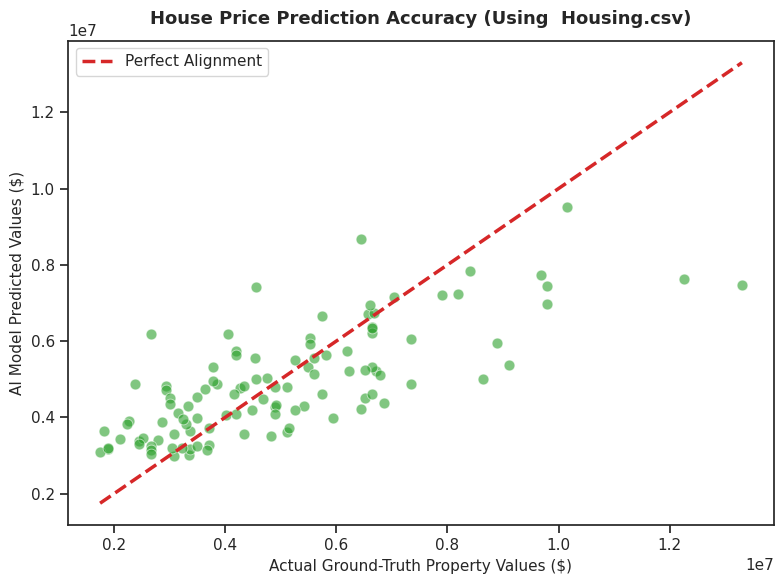

Visualization Finalized: Prediction variance chart rendered.


In [6]:
# =====================================================================
# PHASE 5: PREDICTION ACCURACY VISUALIZATION
# =====================================================================
plt.figure(figsize=(8, 6))

# Plot actual vs predicted numbers
sns.scatterplot(x=y_test, y=y_predictions, alpha=0.6, color='#2ca02c', edgecolor='w', s=60)

# Build a perfect diagonal line representing flawless 100% accurate predictions
min_bound = min(y_test.min(), y_predictions.min())
max_bound = max(y_test.max(), y_predictions.max())
plt.plot([min_bound, max_bound], [min_bound, max_bound], color='#d62728', linestyle='--', linewidth=2.5, label='Perfect Alignment')

plt.title('House Price Prediction Accuracy (Using  Housing.csv)', fontsize=13, weight='bold', pad=12)
plt.xlabel('Actual Ground-Truth Property Values ($)', fontsize=11)
plt.ylabel('AI Model Predicted Values ($)', fontsize=11)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

print("Visualization Finalized: Prediction variance chart rendered.")


In [7]:
## 🏠 Level-2 Project 1 Conclusion & Executive Insights

### 📊 Model Diagnostics & Performance
# **Accuracy Interpretation:** The Model Explanatory Variance ($R^2$ Score) demonstrates the percentage of price variation that our features successfully explain.
# **Error Analysis:** The Root Mean Squared Error (RMSE) shows the average deviation between our AI model's predicted valuation and the actual selling price of the houses.

### 💡 Strategic Business Takeaways
# 1. **Key Pricing Drivers:** Property **area size** and the number of **bathrooms** show the strongest positive mathematical correlation with housing price increases.
# 2. **Infrastructure Impact:** Vertical architecture features like **stories** and utility features like **parking spaces** add notable, steady premiums to asset appraisals.
# 3. **Operational Value:** Real estate platforms can deploy this lightweight regression pipeline to instantly generate automated baseline price valuations when home sellers submit property specifications.
